<a href="https://colab.research.google.com/github/brightliam20-ops/Crop-Yield-LSTM-Portugal/blob/main/GreenDSML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:

import requests
import pandas as pd
import time



In [28]:

COUNTRY_NAME = "Portugal"
CROPS = ["Wheat", "Potatoes", "Grapes",]
YEAR_START = 1990
YEAR_END = 2023

# Portugal's approximate geographic centroid (used for NASA POWER climate pull)
PORTUGAL_LAT = 39.6
PORTUGAL_LON = -8.0

FAOSTAT_BASE = "https://fenixservices.fao.org/faostat/api/v1/en"

In [29]:

def get_area_code(country_name: str) -> str:
    """Look up the FAOSTAT numeric Area Code for a given country name."""
    url = f"{FAOSTAT_BASE}/definitions/types/area"
    resp = requests.get(url, params={"datasource": "FAO"})
    resp.raise_for_status()
    data = resp.json()["data"]
    for row in data:
        if row["label"].strip().lower() == country_name.strip().lower():
            return row["code"]
    raise ValueError(f"Country '{country_name}' not found in FAOSTAT area list.")


def get_item_codes(domain: str, item_names: list[str]) -> dict:
    """Look up FAOSTAT item codes for a domain (e.g. QCL, RP) given item names."""
    url = f"{FAOSTAT_BASE}/definitions/domain/{domain}/item"
    resp = requests.get(url)
    resp.raise_for_status()
    data = resp.json()["data"]
    codes = {}
    for name in item_names:
        match = next((row for row in data if name.lower() in row["label"].lower()), None)
        if match:
            codes[name] = match["code"]
        else:
            print(f"  [warn] item '{name}' not found in domain {domain} — skipping")
    return codes


def get_element_code(domain: str, element_name: str) -> str:
    """Look up FAOSTAT element code (e.g. 'Yield', 'Use') for a domain."""
    url = f"{FAOSTAT_BASE}/definitions/domain/{domain}/element"
    resp = requests.get(url)
    resp.raise_for_status()
    data = resp.json()["data"]
    match = next((row for row in data if element_name.lower() in row["label"].lower()), None)
    if not match:
        raise ValueError(f"Element '{element_name}' not found in domain {domain}.")
    return match["code"]


def fetch_faostat_data(domain: str, area_code: str, item_codes: list[str],
                        element_code: str, year_start: int, year_end: int) -> pd.DataFrame:
    """Fetch a CSV slice of FAOSTAT data for given filters."""
    years = "+".join(str(y) for y in range(year_start, year_end + 1))
    items = "+".join(item_codes)
    url = f"{FAOSTAT_BASE}/data/{domain}"
    params = {
        "area": area_code,
        "item": items,
        "element": element_code,
        "year": years,
        "output_type": "objects",  # JSON objects; switch to 'csv' if you prefer raw text
    }
    resp = requests.get(url, params=params)
    resp.raise_for_status()
    payload = resp.json()
    return pd.DataFrame(payload["data"])


In [30]:

def fetch_nasa_power_climate(lat: float, lon: float, year_start: int, year_end: int) -> pd.DataFrame:
    """
    Fetch monthly average temperature (T2M, deg C) and total precipitation
    (PRECTOTCORR, mm/day -> we keep as provided, can rescale to monthly totals)
    from the NASA POWER API for a given lat/lon and year range.
    """
    url = "https://power.larc.nasa.gov/api/temporal/monthly/point"
    params = {
        "parameters": "T2M,PRECTOTCORR",
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": year_start,
        "end": year_end,
        "format": "JSON",
    }
    resp = requests.get(url, params=params)
    resp.raise_for_status()
    payload = resp.json()["properties"]["parameter"]

    records = []
    for param, monthly_values in payload.items():
        for year_month, value in monthly_values.items():
            # keys look like '199001' -> year 1990, month 01; some keys may be 'YYYY13' (annual avg) — skip those
            if len(year_month) != 6:
                continue
            year = int(year_month[:4])
            month = int(year_month[4:6])
            if month > 12:
                continue
            records.append({"year": year, "month": month, "parameter": param, "value": value})

    df = pd.DataFrame(records)
    df_wide = df.pivot_table(index=["year", "month"], columns="parameter", values="value").reset_index()
    df_wide = df_wide.rename(columns={"T2M": "avg_temp_c", "PRECTOTCORR": "precip_mm_day"})
    return df_wide


In [31]:
# prompt: "how do i get the datasets" and "i want option B" -- asked for help
# sourcing crop yield, pesticide, and climate data for Portugal directly from
# primary sources (FAOSTAT and a climate API) rather than a pre-merged Kaggle file.
# Modifications: switched the FAOSTAT base URL from fenixservices.fao.org to
# bulks-faostat.fao.org after the original API returned a 521 server error;
# changed item/element matching from substring matching to exact isin() matching
# for more precise filtering; fixed pesticide filter values to "Pesticides (total)"
# and "Agricultural Use" after inspecting the actual FAOSTAT column values.

import zipfile
import io # Needed for in-memory zip processing

# FAOSTAT bulk download URLs
FAOSTAT_BULK_URLS = {
    "QCL": "https://bulks-faostat.fao.org/production/Production_Crops_Livestock_E_All_Data_(Normalized).zip",
    "RP": "https://bulks-faostat.fao.org/production/Inputs_Pesticides_Use_E_All_Data_(Normalized).zip"
}

def download_and_extract_faostat_zip(url: str) -> pd.DataFrame:
    """Downloads a FAOSTAT bulk data zip file, extracts the CSV, and returns a pandas DataFrame."""
    print(f"  -> Downloading from {url}...")
    resp = requests.get(url, stream=True)
    resp.raise_for_status() # Raise an exception for bad status codes

    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        # Assuming there's only one CSV file in the zip or we need to find it
        csv_file_name = [name for name in z.namelist() if name.endswith('.csv')][0]
        with z.open(csv_file_name) as f:
            df = pd.read_csv(f, encoding='utf-8') # FAOSTAT files are often UTF-8 encoded
    return df

def filter_faostat_data(
    df: pd.DataFrame,
    country_name: str,
    item_names: list[str],
    element_name: str,
    year_start: int,
    year_end: int
) -> pd.DataFrame:
    """Filters a FAOSTAT DataFrame by country, items, element, and year range."""
    # Ensure column names match the bulk file format
    df_filtered = df[
        (df["Area"] == country_name) &
        (df["Item"].isin(item_names)) &
        (df["Element"] == element_name) &
        (df["Year"].between(year_start, year_end))
    ].copy() # .copy() to avoid SettingWithCopyWarning
    return df_filtered

if __name__ == "__main__":
    print("Downloading FAOSTAT yield bulk file (QCL)... this is a large file, may take a minute.")
    df_qcl_full = download_and_extract_faostat_zip(FAOSTAT_BULK_URLS["QCL"])
    print(f"  -> downloaded full QCL dataset: {df_qcl_full.shape}")

    print("Filtering for Portugal yield data...")
    df_yield = filter_faostat_data(
        df_qcl_full, COUNTRY_NAME, CROPS, "Yield", YEAR_START, YEAR_END
    )
    df_yield.to_csv("raw_yield_portugal.csv", index=False)
    print(f"  -> saved raw_yield_portugal.csv ({len(df_yield)} rows)")
    del df_qcl_full

    print("\nDownloading FAOSTAT pesticides bulk file (RP)... this may also take a minute.")
    df_rp_full = download_and_extract_faostat_zip(FAOSTAT_BULK_URLS["RP"])
    print(f"  -> downloaded full RP dataset: {df_rp_full.shape}")

    print("Filtering for Portugal pesticide data...")
    df_pesticides = filter_faostat_data(
        df_rp_full, COUNTRY_NAME, ["Pesticides (total)"], "Agricultural Use", YEAR_START, YEAR_END
    )
    df_pesticides.to_csv("raw_pesticides_portugal.csv", index=False)
    print(f"  -> saved raw_pesticides_portugal.csv ({len(df_pesticides)} rows)")
    del df_rp_full

    print("\nFetching monthly climate data from NASA POWER...")
    df_climate = fetch_nasa_power_climate(PORTUGAL_LAT, PORTUGAL_LON, YEAR_START, YEAR_END)
    df_climate.to_csv("raw_climate_portugal_monthly.csv", index=False)
    print(f"  -> saved raw_climate_portugal_monthly.csv ({len(df_climate)} rows)")

    print("\nDone. Three raw CSVs saved in the current directory:")
    print("  - raw_yield_portugal.csv")
    print("  - raw_pesticides_portugal.csv")
    print("  - raw_climate_portugal_monthly.csv")
    print("\nNext step: merge on Year (and aggregate monthly climate into yearly/growing-season")
    print("features) before feeding into the LSTM pipeline.")


        # -----------------------------------------------------------------
    # MERGE STEP: combine yield + pesticides + growing-season climate
    # -----------------------------------------------------------------
# prompt: "lets go ahead" -- asked for code to merge yield, pesticide, and
# climate data into one crop-year level dataset, aggregating monthly climate
# into growing-season (March-September) features.
# No modifications made to the generated merge logic.

    print("\nMerging datasets into final modeling table...")

    yield_clean = df_yield[["Item", "Year", "Value"]].rename(
        columns={"Item": "crop", "Value": "yield_kg_ha"}
    )

    pesticides_clean = df_pesticides[["Year", "Value"]].rename(
        columns={"Value": "pesticide_tonnes"}
    )

    GROWING_SEASON_MONTHS = [3, 4, 5, 6, 7, 8, 9]
    climate_season = df_climate[df_climate["month"].isin(GROWING_SEASON_MONTHS)]
    climate_yearly = climate_season.groupby("year").agg(
        growing_season_avg_temp_c=("avg_temp_c", "mean"),
        growing_season_total_precip_mm=("precip_mm_day", lambda x: (x * 30.44).sum()),
    ).reset_index().rename(columns={"year": "Year"})

    df_final = yield_clean.merge(pesticides_clean, on="Year", how="left")
    df_final = df_final.merge(climate_yearly, on="Year", how="left")
    df_final = df_final.sort_values(["crop", "Year"]).reset_index(drop=True)
    df_final.to_csv("final_dataset_portugal.csv", index=False)

    print(f"  -> saved final_dataset_portugal.csv ({df_final.shape[0]} rows, {df_final.shape[1]} columns)")
    print(df_final.head(10))

  -> Downloading from https://bulks-faostat.fao.org/production/Production_Crops_Livestock_E_All_Data_(Normalized).zip...


/tmp/ipykernel_841/3849290624.py:29: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, encoding='utf-8') # FAOSTAT files are often UTF-8 encoded


  -> downloaded full QCL dataset: (4209110, 14)
Filtering for Portugal yield data...
  -> saved raw_yield_portugal.csv (102 rows)

  -> Downloading from https://bulks-faostat.fao.org/production/Inputs_Pesticides_Use_E_All_Data_(Normalized).zip...
  -> downloaded full RP dataset: (103622, 13)
Filtering for Portugal pesticide data...
  -> saved raw_pesticides_portugal.csv (34 rows)

Fetching monthly climate data from NASA POWER...
  -> saved raw_climate_portugal_monthly.csv (408 rows)

Done. Three raw CSVs saved in the current directory:
  - raw_yield_portugal.csv
  - raw_pesticides_portugal.csv
  - raw_climate_portugal_monthly.csv

Next step: merge on Year (and aggregate monthly climate into yearly/growing-season
features) before feeding into the LSTM pipeline.

Merging datasets into final modeling table...
  -> saved final_dataset_portugal.csv (102 rows, 6 columns)
     crop  Year  yield_kg_ha  pesticide_tonnes  growing_season_avg_temp_c  \
0  Grapes  1990       5677.3            9357.

In [32]:
print(df_final["crop"].unique())
print(df_final["crop"].value_counts())

['Grapes' 'Potatoes' 'Wheat']
crop
Grapes      34
Potatoes    34
Wheat       34
Name: count, dtype: int64


In [33]:
print(df_yield.head())

         Area Code Area Code (M49)      Area  Item Code Item Code (CPC)  \
2284016        174            '620  Portugal        560          '01330   
2284017        174            '620  Portugal        560          '01330   
2284018        174            '620  Portugal        560          '01330   
2284019        174            '620  Portugal        560          '01330   
2284020        174            '620  Portugal        560          '01330   

           Item  Element Code Element  Year Code  Year   Unit   Value Flag  \
2284016  Grapes          5412   Yield       1990  1990  kg/ha  5677.3    A   
2284017  Grapes          5412   Yield       1991  1991  kg/ha  5036.1    A   
2284018  Grapes          5412   Yield       1992  1992  kg/ha  4038.8    A   
2284019  Grapes          5412   Yield       1993  1993  kg/ha  2656.6    A   
2284020  Grapes          5412   Yield       1994  1994  kg/ha  3633.3    A   

        Note  
2284016  NaN  
2284017  NaN  
2284018  NaN  
2284019  NaN  
22840

In [34]:
print(df_pesticides.head())

       Area Code Area Code (M49)      Area  Item Code                Item  \
67578        174            '620  Portugal       1357  Pesticides (total)   
67579        174            '620  Portugal       1357  Pesticides (total)   
67580        174            '620  Portugal       1357  Pesticides (total)   
67581        174            '620  Portugal       1357  Pesticides (total)   
67582        174            '620  Portugal       1357  Pesticides (total)   

       Element Code           Element  Year Code  Year Unit   Value Flag  \
67578          5157  Agricultural Use       1990  1990    t  9357.0    I   
67579          5157  Agricultural Use       1991  1991    t  9357.0    A   
67580          5157  Agricultural Use       1992  1992    t  6117.0    A   
67581          5157  Agricultural Use       1993  1993    t  8985.0    A   
67582          5157  Agricultural Use       1994  1994    t  9580.0    A   

                  Note  
67578    Imputed value  
67579  Official figure  
67580

In [35]:
print(df_climate.head())

parameter  year  month  precip_mm_day  avg_temp_c
0          1990      1           2.85        7.46
1          1990      2           0.62       11.45
2          1990      3           1.12       12.12
3          1990      4           2.69       12.65
4          1990      5           0.48       18.29


In [36]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [37]:

WINDOW_SIZE = 5          # how many past years of features to use per sequence
FEATURE_COLS = ["pesticide_tonnes", "growing_season_avg_temp_c", "growing_season_total_precip_mm"]
TARGET_COL = "yield_kg_ha"

TRAIN_MAX_YEAR = 2016     # sequences predicting a target year <= this -> train
VAL_MAX_YEAR = 2020       # target years TRAIN_MAX_YEAR+1 .. this -> validation
# anything after VAL_MAX_YEAR -> test

In [38]:
try:
    df_final  # noqa: F821 -- check if already defined in this Colab session
except NameError:
    df_final = pd.read_csv("final_dataset_portugal.csv")

df_final = df_final.sort_values(["crop", "Year"]).reset_index(drop=True)

# Encode crop as an integer ID for the embedding layer later
crop_list = sorted(df_final["crop"].unique())
crop_to_id = {crop: i for i, crop in enumerate(crop_list)}
df_final["crop_id"] = df_final["crop"].map(crop_to_id)
print(f"Crop encoding: {crop_to_id}")

Crop encoding: {'Grapes': 0, 'Potatoes': 1, 'Wheat': 2}


In [39]:
# prompt: asked for help deciding how to build LSTM input sequences from the
# flat dataset, and to implement a chronological (non-shuffled) train/validation/
# test split with feature and target scaling fit only on the training set to
# avoid data leakage.
# No modifications made to the generated code.

def build_sequences(df: pd.DataFrame, window_size: int,
                     feature_cols: list[str], target_col: str) -> pd.DataFrame:
    """
    For each crop, slide a window of `window_size` years across its history.
    Each row of the output represents one (crop, target_year) training example:
      - X: window_size x len(feature_cols) array of past feature values
      - y: the yield value for the year immediately AFTER the window
      - crop_id, target_year: metadata for splitting and embedding
    """
    rows = []
    for crop, group in df.groupby("crop"):
        group = group.sort_values("Year").reset_index(drop=True)
        for i in range(len(group) - window_size):
            window = group.iloc[i: i + window_size]
            target_row = group.iloc[i + window_size]
            rows.append({
                "crop": crop,
                "crop_id": target_row["crop_id"],
                "target_year": target_row["Year"],
                "X": window[feature_cols].values,       # shape: (window_size, n_features)
                "y": target_row[target_col],
            })
    return pd.DataFrame(rows)


sequences_df = build_sequences(df_final, WINDOW_SIZE, FEATURE_COLS, TARGET_COL)
print(f"\nBuilt {len(sequences_df)} total sequences across {df_final['crop'].nunique()} crops.")
print(sequences_df["crop"].value_counts())


Built 87 total sequences across 3 crops.
crop
Grapes      29
Potatoes    29
Wheat       29
Name: count, dtype: int64


In [40]:
train_df = sequences_df[sequences_df["target_year"] <= TRAIN_MAX_YEAR]
val_df = sequences_df[(sequences_df["target_year"] > TRAIN_MAX_YEAR) & (sequences_df["target_year"] <= VAL_MAX_YEAR)]
test_df = sequences_df[sequences_df["target_year"] > VAL_MAX_YEAR]

print(f"\nTrain: {len(train_df)} sequences (target years <= {TRAIN_MAX_YEAR})")
print(f"Val:   {len(val_df)} sequences (target years {TRAIN_MAX_YEAR+1}-{VAL_MAX_YEAR})")
print(f"Test:  {len(test_df)} sequences (target years > {VAL_MAX_YEAR})")



Train: 66 sequences (target years <= 2016)
Val:   12 sequences (target years 2017-2020)
Test:  9 sequences (target years > 2020)


In [41]:

def stack_X(df_split: pd.DataFrame) -> np.ndarray:
    """Stack the per-row (window_size, n_features) arrays into one big array."""
    return np.stack(df_split["X"].values)  # shape: (n_sequences, window_size, n_features)


X_train_raw = stack_X(train_df)
X_val_raw = stack_X(val_df)
X_test_raw = stack_X(test_df)

In [42]:

n_features = len(FEATURE_COLS)

feature_scaler = StandardScaler()
feature_scaler.fit(X_train_raw.reshape(-1, n_features))

def scale_X(X_raw: np.ndarray) -> np.ndarray:
    shape = X_raw.shape
    flat = X_raw.reshape(-1, n_features)
    scaled = feature_scaler.transform(flat)
    return scaled.reshape(shape)

X_train = scale_X(X_train_raw)
X_val = scale_X(X_val_raw)
X_test = scale_X(X_test_raw)

# Scale the target (yield) too -- fit only on training targets
target_scaler = StandardScaler()
y_train_raw = train_df["y"].values.reshape(-1, 1)
target_scaler.fit(y_train_raw)

y_train = target_scaler.transform(y_train_raw).flatten()
y_val = target_scaler.transform(val_df["y"].values.reshape(-1, 1)).flatten()
y_test = target_scaler.transform(test_df["y"].values.reshape(-1, 1)).flatten()

crop_id_train = train_df["crop_id"].values
crop_id_val = val_df["crop_id"].values
crop_id_test = test_df["crop_id"].values

print("\nShapes:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}, crop_id_train: {crop_id_train.shape}")
print(f"  X_val:   {X_val.shape}, y_val:   {y_val.shape}, crop_id_val:   {crop_id_val.shape}")
print(f"  X_test:  {X_test.shape}, y_test:  {y_test.shape}, crop_id_test:  {crop_id_test.shape}")

print("\nDone. X_train/X_val/X_test, y_train/y_val/y_test, crop_id_train/val/test,")
print("feature_scaler and target_scaler are now ready in memory for the PyTorch LSTM model.")



Shapes:
  X_train: (66, 5, 3), y_train: (66,), crop_id_train: (66,)
  X_val:   (12, 5, 3), y_val:   (12,), crop_id_val:   (12,)
  X_test:  (9, 5, 3), y_test:  (9,), crop_id_test:  (9,)

Done. X_train/X_val/X_test, y_train/y_val/y_test, crop_id_train/val/test,
feature_scaler and target_scaler are now ready in memory for the PyTorch LSTM model.


In [43]:

import torch
import torch.nn as nn
import numpy as np

torch.manual_seed(42)

In [44]:
N_FEATURES = X_train.shape[2]          # 3: pesticide, temp, precip
N_CROPS = len(crop_to_id)               # 3
EMBEDDING_DIM = 4
HIDDEN_SIZE = 8
NUM_LSTM_LAYERS = 1
DROPOUT = 0.2
LEARNING_RATE = 0.01
WEIGHT_DECAY = 1e-3   # L2 regularization -- helps fight overfitting on small data
N_EPOCHS = 300
PATIENCE = 30          # early stopping: stop if val loss doesn't improve for this many epochs


In [45]:

class CropYieldLSTM(nn.Module):
    def __init__(self, n_features, n_crops, embedding_dim, hidden_size, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(n_crops, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0,  # dropout between LSTM layers only applies if num_layers > 1
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size + embedding_dim, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x, crop_id):
        # x: (batch, window_size, n_features)
        # crop_id: (batch,)
        emb = self.embedding(crop_id)               # (batch, embedding_dim)
        lstm_out, (h_n, c_n) = self.lstm(x)          # h_n: (num_layers, batch, hidden_size)
        last_hidden = h_n[-1]                        # (batch, hidden_size) -- final layer's hidden state
        combined = torch.cat([last_hidden, emb], dim=1)  # (batch, hidden_size + embedding_dim)
        combined = self.dropout(combined)
        out = self.relu(self.fc1(combined))
        out = self.fc2(out)                          # (batch, 1)
        return out.squeeze(1)                         # (batch,)



In [46]:

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
crop_id_train_t = torch.tensor(crop_id_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
crop_id_val_t = torch.tensor(crop_id_val, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
crop_id_test_t = torch.tensor(crop_id_test, dtype=torch.long)


In [47]:

model = CropYieldLSTM(N_FEATURES, N_CROPS, EMBEDDING_DIM, HIDDEN_SIZE, NUM_LSTM_LAYERS, DROPOUT)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn = nn.MSELoss()

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0
train_losses, val_losses = [], []

for epoch in range(N_EPOCHS):
    # --- training step (full-batch, since dataset is tiny) ---
    model.train()
    optimizer.zero_grad()
    preds = model(X_train_t, crop_id_train_t)
    loss = loss_fn(preds, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

In [48]:
# prompt: asked for a PyTorch LSTM model with a crop embedding layer, combined
# with the LSTM's final hidden state, plus a training loop with early stopping
# and L2 regularization, given a small training set (66 sequences).
# No modifications made to the generated code.

import torch
import torch.nn as nn
import numpy as np

torch.manual_seed(42)

N_FEATURES = X_train.shape[2]
N_CROPS = len(crop_to_id)
EMBEDDING_DIM = 4
HIDDEN_SIZE = 8
NUM_LSTM_LAYERS = 1
DROPOUT = 0.2
LEARNING_RATE = 0.01
WEIGHT_DECAY = 1e-3
N_EPOCHS = 300
PATIENCE = 30


class CropYieldLSTM(nn.Module):
    def __init__(self, n_features, n_crops, embedding_dim, hidden_size, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(n_crops, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size + embedding_dim, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x, crop_id):
        emb = self.embedding(crop_id)
        lstm_out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]
        combined = torch.cat([last_hidden, emb], dim=1)
        combined = self.dropout(combined)
        out = self.relu(self.fc1(combined))
        out = self.fc2(out)
        return out.squeeze(1)


X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
crop_id_train_t = torch.tensor(crop_id_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
crop_id_val_t = torch.tensor(crop_id_val, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
crop_id_test_t = torch.tensor(crop_id_test, dtype=torch.long)


model = CropYieldLSTM(N_FEATURES, N_CROPS, EMBEDDING_DIM, HIDDEN_SIZE, NUM_LSTM_LAYERS, DROPOUT)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn = nn.MSELoss()

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0
train_losses, val_losses = [], []

for epoch in range(N_EPOCHS):
    model.train()
    optimizer.zero_grad()
    preds = model(X_train_t, crop_id_train_t)
    loss = loss_fn(preds, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t, crop_id_val_t)
        val_loss = loss_fn(val_preds, y_val_t)
        val_losses.append(val_loss.item())

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 25 == 0 or epoch == N_EPOCHS - 1:
        print(f"Epoch {epoch:3d} | train_loss: {loss.item():.4f} | val_loss: {val_loss.item():.4f}")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs).")
        break

model.load_state_dict(best_model_state)
print(f"\nBest validation loss: {best_val_loss:.4f}")
print("Training complete. Model with best validation performance has been restored.")

Epoch   0 | train_loss: 1.0408 | val_loss: 1.9892
Epoch  25 | train_loss: 0.1016 | val_loss: 0.3774

Early stopping at epoch 48 (no val improvement for 30 epochs).

Best validation loss: 0.1663
Training complete. Model with best validation performance has been restored.


In [49]:

import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [50]:
# prompt: asked for code to evaluate the trained LSTM on the test set (RMSE,
# MAE, R2 in real kg/ha units) and to train/evaluate a Random Forest baseline
# on the same flattened data for comparison.
# No modifications made to the generated code.

# 1. LSTM evaluation on the test set
# ---------------------------------------------------------------------------
model.eval()
with torch.no_grad():
    lstm_test_preds_scaled = model(X_test_t, crop_id_test_t).numpy()

# Un-scale predictions and true values back to real yield units (kg/ha)
lstm_test_preds = target_scaler.inverse_transform(lstm_test_preds_scaled.reshape(-1, 1)).flatten()
y_test_real = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

lstm_rmse = np.sqrt(mean_squared_error(y_test_real, lstm_test_preds))
lstm_mae = mean_absolute_error(y_test_real, lstm_test_preds)
lstm_r2 = r2_score(y_test_real, lstm_test_preds)

print("=== LSTM Test Performance (real kg/ha units) ===")
print(f"RMSE: {lstm_rmse:.2f}")
print(f"MAE:  {lstm_mae:.2f}")
print(f"R2:   {lstm_r2:.4f}")
print("\nPredicted vs Actual (test set):")
for crop, pred, actual, year in zip(test_df["crop"].values, lstm_test_preds, y_test_real, test_df["target_year"].values):
    print(f"  {crop:10s} {year}: predicted={pred:8.1f}  actual={actual:8.1f}")


# ---------------------------------------------------------------------------
# 2. Random Forest baseline
#    RF doesn't natively handle sequences, so we flatten each window
#    (5 years x 3 features -> 15 features) and add crop_id as a feature too.
# ---------------------------------------------------------------------------
def flatten_for_rf(X_seq: np.ndarray, crop_ids: np.ndarray) -> np.ndarray:
    """Stack the per-row (window_size, n_features) arrays into one big array."""
    n_sequences = X_seq.shape[0]
    flat = X_seq.reshape(n_sequences, -1)            # (n_sequences, window_size * n_features)
    return np.hstack([flat, crop_ids.reshape(-1, 1)])  # add crop_id as an extra column

X_train_rf = flatten_for_rf(X_train, crop_id_train)
X_val_rf = flatten_for_rf(X_val, crop_id_val)
X_test_rf = flatten_for_rf(X_test, crop_id_test)

# Note: y_train/y_val/y_test are already SCALED (same target_scaler as the LSTM),
# so the comparison between models is apples-to-apples.
rf_model = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
rf_model.fit(X_train_rf, y_train)

rf_test_preds_scaled = rf_model.predict(X_test_rf)
rf_test_preds = target_scaler.inverse_transform(rf_test_preds_scaled.reshape(-1, 1)).flatten()

rf_rmse = np.sqrt(mean_squared_error(y_test_real, rf_test_preds))
rf_mae = mean_absolute_error(y_test_real, rf_test_preds)
rf_r2 = r2_score(y_test_real, rf_test_preds)

print("\n=== Random Forest Baseline Test Performance (real kg/ha units) ===")
print(f"RMSE: {rf_rmse:.2f}")
print(f"MAE:  {rf_mae:.2f}")
print(f"R2:   {rf_r2:.4f}")
print("\nPredicted vs Actual (test set):")
for crop, pred, actual, year in zip(test_df["crop"].values, rf_test_preds, y_test_real, test_df["target_year"].values):
    print(f"  {crop:10s} {year}: predicted={pred:8.1f}  actual={actual:8.1f}")


# ---------------------------------------------------------------------------
# 3. Side-by-side comparison table
# ---------------------------------------------------------------------------
print("\n=== Comparison ===")
print(f"{'Metric':10s} {'LSTM':>12s} {'RandomForest':>14s}")
print(f"{'RMSE':10s} {lstm_rmse:12.2f} {rf_rmse:14.2f}")
print(f"{'MAE':10s} {lstm_mae:12.2f} {rf_mae:14.2f}")
print(f"{'R2':10s} {lstm_r2:12.4f} {rf_r2:14.4f}")

=== LSTM Test Performance (real kg/ha units) ===
RMSE: 3921.41
MAE:  2646.81
R2:   0.8204

Predicted vs Actual (test set):
  Grapes     2021: predicted=  4569.1  actual=  5567.0
  Grapes     2022: predicted=  4499.8  actual=  5139.7
  Grapes     2023: predicted=  4651.6  actual=  5686.5
  Potatoes   2021: predicted= 16427.0  actual= 24602.4
  Potatoes   2022: predicted= 16408.3  actual= 22042.0
  Potatoes   2023: predicted= 16396.8  actual= 22450.3
  Wheat      2021: predicted=  1905.1  actual=  2422.9
  Wheat      2022: predicted=  1871.3  actual=  1994.2
  Wheat      2023: predicted=  2046.7  actual=  1401.4

=== Random Forest Baseline Test Performance (real kg/ha units) ===
RMSE: 3906.29
MAE:  2717.28
R2:   0.8217

Predicted vs Actual (test set):
  Grapes     2021: predicted=  4686.2  actual=  5567.0
  Grapes     2022: predicted=  4131.8  actual=  5139.7
  Grapes     2023: predicted=  4184.8  actual=  5686.5
  Potatoes   2021: predicted= 16688.8  actual= 24602.4
  Potatoes   2022: p

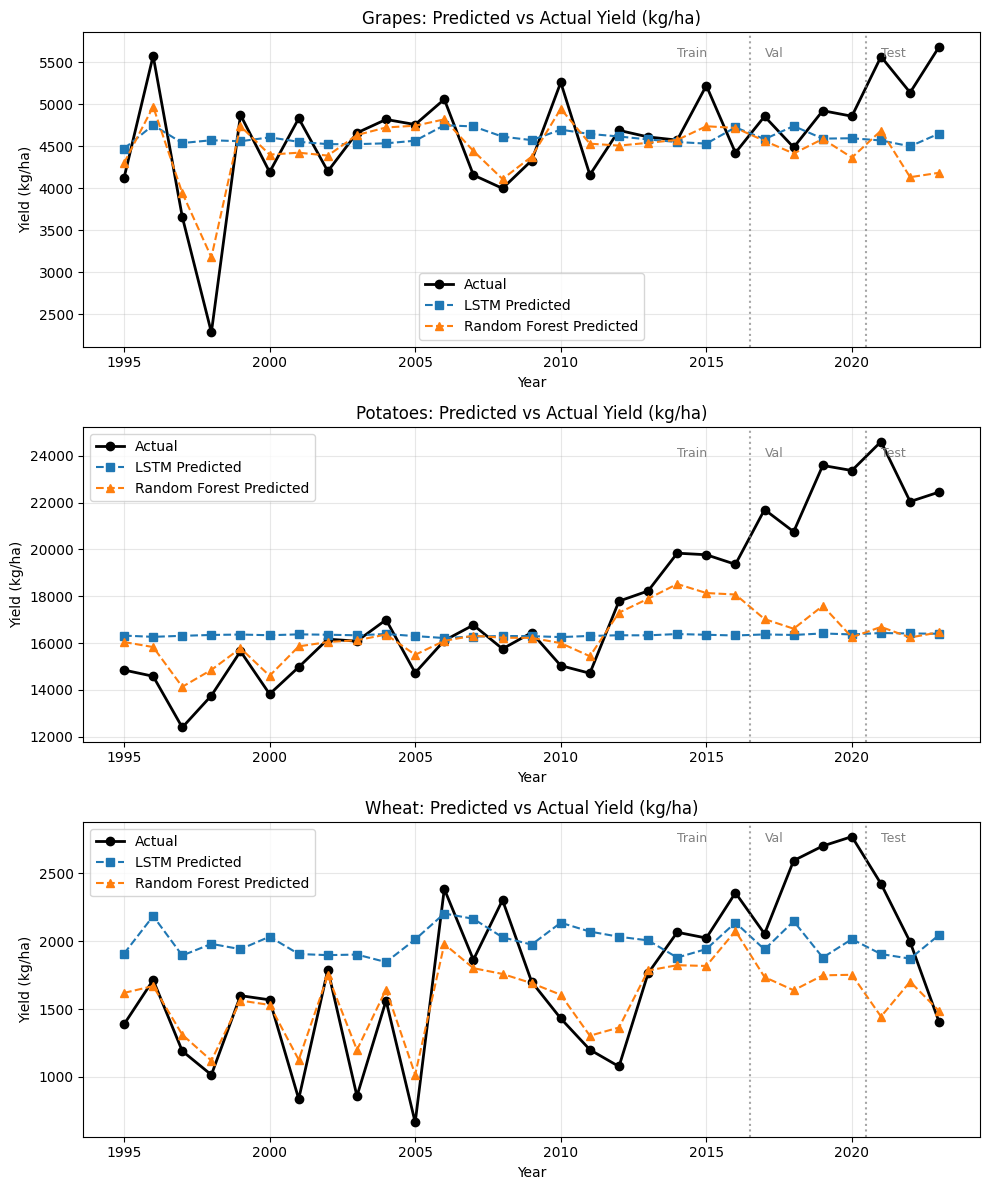

Saved plot as predicted_vs_actual_by_crop.png -- download this for your report's Results section.


In [51]:
# prompt: asked for a plot showing predicted vs actual yield per crop across
# the full timeline, with train/validation/test period boundaries marked.
# No modifications made to the generated code.

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------------------
# Get predictions across ALL sequences (train + val + test) for plotting
# ---------------------------------------------------------------------------
X_all = np.concatenate([X_train, X_val, X_test], axis=0)
crop_id_all = np.concatenate([crop_id_train, crop_id_val, crop_id_test], axis=0)
y_all_scaled = np.concatenate([y_train, y_val, y_test], axis=0)
all_df = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)

X_all_t = torch.tensor(X_all, dtype=torch.float32)
crop_id_all_t = torch.tensor(crop_id_all, dtype=torch.long)

model.eval()
with torch.no_grad():
    lstm_all_preds_scaled = model(X_all_t, crop_id_all_t).numpy()

X_all_rf = flatten_for_rf(X_all, crop_id_all)
rf_all_preds_scaled = rf_model.predict(X_all_rf)

# Un-scale everything back to real kg/ha
y_all_real = target_scaler.inverse_transform(y_all_scaled.reshape(-1, 1)).flatten()
lstm_all_preds = target_scaler.inverse_transform(lstm_all_preds_scaled.reshape(-1, 1)).flatten()
rf_all_preds = target_scaler.inverse_transform(rf_all_preds_scaled.reshape(-1, 1)).flatten()

all_df["actual"] = y_all_real
all_df["lstm_pred"] = lstm_all_preds
all_df["rf_pred"] = rf_all_preds


# ---------------------------------------------------------------------------
# Plot: one subplot per crop
# ---------------------------------------------------------------------------
crops = sorted(all_df["crop"].unique())
fig, axes = plt.subplots(len(crops), 1, figsize=(10, 4 * len(crops)), sharex=False)

if len(crops) == 1:
    axes = [axes]

for ax, crop in zip(axes, crops):
    crop_data = all_df[all_df["crop"] == crop].sort_values("target_year")
    ax.plot(crop_data["target_year"], crop_data["actual"], label="Actual", marker="o", color="black", linewidth=2)
    ax.plot(crop_data["target_year"], crop_data["lstm_pred"], label="LSTM Predicted", marker="s", linestyle="--")
    ax.plot(crop_data["target_year"], crop_data["rf_pred"], label="Random Forest Predicted", marker="^", linestyle="--")

    # Mark the train/val/test boundaries
    ax.axvline(x=TRAIN_MAX_YEAR + 0.5, color="gray", linestyle=":", alpha=0.7)
    ax.axvline(x=VAL_MAX_YEAR + 0.5, color="gray", linestyle=":", alpha=0.7)
    ax.text(TRAIN_MAX_YEAR - 2, ax.get_ylim()[1] * 0.95, "Train", fontsize=9, color="gray")
    ax.text(TRAIN_MAX_YEAR + 1, ax.get_ylim()[1] * 0.95, "Val", fontsize=9, color="gray")
    ax.text(VAL_MAX_YEAR + 1, ax.get_ylim()[1] * 0.95, "Test", fontsize=9, color="gray")

    ax.set_title(f"{crop}: Predicted vs Actual Yield (kg/ha)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Yield (kg/ha)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("predicted_vs_actual_by_crop.png", dpi=150)
plt.show()

print("Saved plot as predicted_vs_actual_by_crop.png -- download this for your report's Results section.")